# Dynamisches Preisoptimierungsmodell – Prototyp

**Studienarbeit: Dynamisches Preisoptimierungsmodell im eCommerce**  
*Andreas Traut*

---

## Überblick

Dieser Prototyp demonstriert den End-to-End-Datenfluss des dynamischen
Preisoptimierungssystems:

```
Synthetische CSV-Daten
        ↓
   SQLite-Datenbank  (simuliert SQL Server PricingPrototypeDB)
        ↓
  Feature Engineering (pandas / numpy)
        ↓
  ML-Modell – Preiselastizität (scikit-learn, Log-Log-Regression)
        ↓
  Preisempfehlung (Amoroso-Robinson + Business Rules)
        ↓
  dbo.ModelOutput → Power BI / Reporting
```

### CRISP-DM Einordnung
| Phase | Implementierung |
|---|---|
| Business Understanding | Problemstellung: Statische Preise sub-optimal |
| Data Understanding | Synthetische Daten: Verkäufe, Wettbewerb, Produkte |
| Data Preparation | Feature Engineering in `src/data_preparation.py` |
| Modeling | Log-Log-Regression in `src/model.py` |
| Evaluation | R², MAE, RMSE + Plausibilitätsprüfung Elastizitäten |
| Deployment | `dbo.ModelOutput` + Visualisierung in diesem Notebook |


In [1]:
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)


## 1  Datenintegration (ETL-Simulation)

In [2]:
from src.data_preparation import load_csv_to_db, build_feature_dataframe, get_connection

# Synthetische CSV-Daten → SQLite (simuliert SSIS / BULK INSERT)
load_csv_to_db()

# Feature-DataFrame aufbauen
df = build_feature_dataframe()
print(f"DataFrame: {df.shape[0]} Zeilen, {df.shape[1]} Spalten")
df.head()


ETL abgeschlossen: Daten in PricingPrototypeDB.sqlite geladen.
DataFrame: 1825 Zeilen, 23 Spalten


,verkauf_id,produkt_id,datum,menge,preis,umsatz,listenpreis,einstandspreis,kategorie,wettbewerbspreis,...,ist_wochenende,log_preis,preis_relativ_zu_listenpreis,preis_relativ_zu_wettbewerb,rollierender_umsatz_7d,rollierender_umsatz_30d,rollierender_preis_7d,log_menge,kategorie_code,produkt_code
0,1,P001,2023-01-01,41,65.25,2675.25,59.99,30.0,Elektronik,NaN,...,1,4.178226,1.087681,1.000000,2675.2500,2675.2500,65.250000,3.713572,0,0
1,2,P001,2023-01-02,69,53.33,3679.77,59.99,30.0,Elektronik,64.92,...,0,3.976499,0.888981,0.821473,3177.5100,3177.5100,59.290000,4.234107,0,0
2,3,P001,2023-01-03,69,53.33,3679.77,59.99,30.0,Elektronik,64.92,...,0,3.976499,0.888981,0.821473,3344.9300,3344.9300,57.303333,4.234107,0,0
3,4,P001,2023-01-04,66,51.30,3385.80,59.99,30.0,Elektronik,64.92,...,0,3.937691,0.855143,0.790203,3355.1475,3355.1475,55.802500,4.189655,0,0
4,5,P001,2023-01-05,35,65.54,2293.90,59.99,30.0,Elektronik,64.92,...,0,4.182661,1.092515,1.009550,3142.8980,3142.8980,57.750000,3.555348,0,0


## 2  Explorative Datenanalyse (EDA)

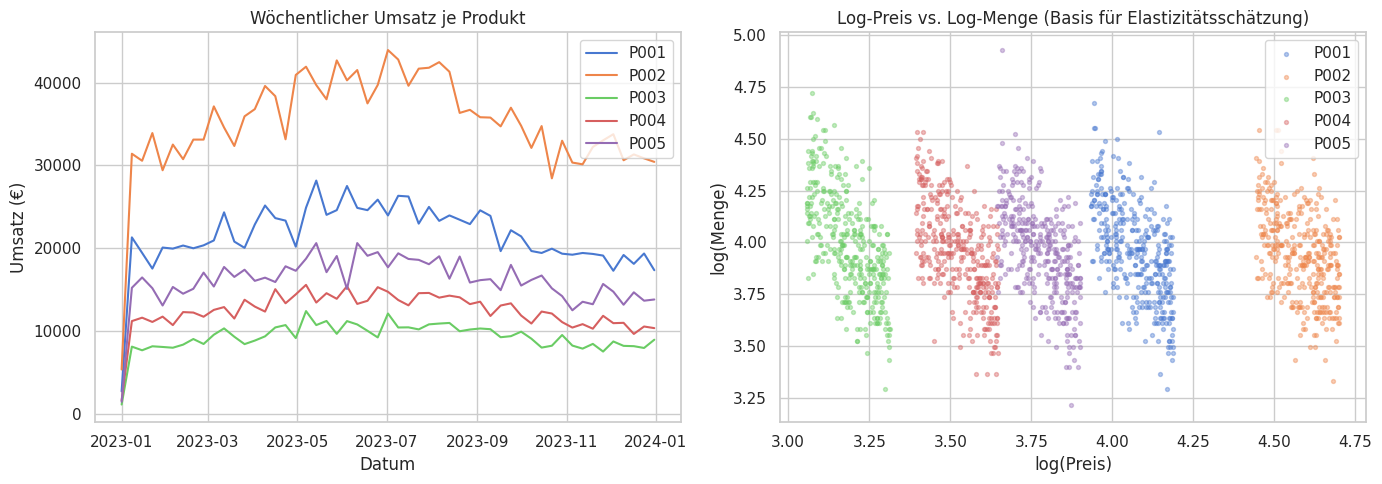

In [3]:
# --- Umsatz je Produkt im Zeitverlauf ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for pid, grp in df.groupby("produkt_id"):
    weekly = grp.set_index("datum").resample("W")["umsatz"].sum()
    axes[0].plot(weekly.index, weekly.values, label=pid)

axes[0].set_title("Wöchentlicher Umsatz je Produkt")
axes[0].set_xlabel("Datum")
axes[0].set_ylabel("Umsatz (€)")
axes[0].legend()

# --- Preis-Mengen-Streudiagramm (log-log) ---
for pid, grp in df.groupby("produkt_id"):
    axes[1].scatter(grp["log_preis"], grp["log_menge"],
                    s=8, alpha=0.4, label=pid)

axes[1].set_title("Log-Preis vs. Log-Menge (Basis für Elastizitätsschätzung)")
axes[1].set_xlabel("log(Preis)")
axes[1].set_ylabel("log(Menge)")
axes[1].legend()

plt.tight_layout()
plt.show()


## 3  Feature Engineering

Die folgenden Features werden für das Modell erstellt:

| Feature | Beschreibung |
|---|---|
| `log_preis` | Logarithmus des Tagespreises |
| `monat`, `quartal` | Saisonalitätsmerkmale |
| `ist_wochenende` | 1 wenn Samstag/Sonntag |
| `preis_relativ_zu_listenpreis` | Aktionserkennung |
| `preis_relativ_zu_wettbewerb` | Wettbewerbspositionierung |
| `rollierender_umsatz_7d` | Kurzfristiger Trend |
| `rollierender_preis_7d` | Rollierender Durchschnittspreis |


In [4]:
feature_cols = [
    "log_preis", "monat", "quartal", "ist_wochenende",
    "preis_relativ_zu_listenpreis", "preis_relativ_zu_wettbewerb",
    "rollierender_umsatz_7d", "rollierender_preis_7d",
]
df[feature_cols + ["log_menge"]].describe().round(3)


,log_preis,monat,quartal,ist_wochenende,preis_relativ_zu_listenpreis,preis_relativ_zu_wettbewerb,rollierender_umsatz_7d,rollierender_preis_7d,log_menge
count,1825.000,1825.000,1825.000,1825.000,1825.000,1825.000,1825.000,1825.000,1825.000
mean,3.829,6.526,2.510,0.288,0.976,0.960,2747.606,51.758,3.962
std,0.482,3.449,1.117,0.453,0.073,0.098,1377.120,25.750,0.230
min,3.057,1.000,1.000,0.000,0.850,0.740,969.593,22.465,3.219
25%,3.459,4.000,2.000,0.000,0.912,0.885,1658.746,33.376,3.807
50%,3.781,7.000,3.000,0.000,0.977,0.959,2326.064,43.930,3.951
75%,4.142,10.000,4.000,1.000,1.041,1.031,3462.133,60.127,4.111
max,4.700,12.000,4.000,1.000,1.100,1.209,6542.310,105.553,4.927


## 4  Modelltraining – Preiselastizität

**Log-Log-Regression** (Ridge):

$$\log(Q) = \alpha + \varepsilon \cdot \log(P) + \beta_1 x_1 + \ldots + \beta_n x_n$$

Der Koeffizient $\varepsilon$ entspricht direkt der **Preiselastizität der Nachfrage**.


In [5]:
from src.model import train_all_products

print("Trainiere Elastizitätsmodelle (je Produkt separat) ...")
results = train_all_products(df)

# Ergebnistabelle
rows = []
for res in results.values():
    rows.append({
        "Produkt": res.produkt_id,
        "Preiselastizität ε": res.elastizitaet,
        "R²": res.r2,
        "MAE": res.mae,
        "RMSE": res.rmse,
    })
df_metrics = pd.DataFrame(rows).set_index("Produkt")
df_metrics


Trainiere Elastizitätsmodelle (je Produkt separat) ...
  P001: ε = -1.183  R² = 0.609  MAE = 0.111
  P002: ε = -1.047  R² = 0.417  MAE = 0.109
  P003: ε = -1.317  R² = 0.570  MAE = 0.117
  P004: ε = -0.525  R² = 0.499  MAE = 0.116
  P005: ε = -0.656  R² = 0.442  MAE = 0.120


,Preiselastizität ε,R²,MAE,RMSE
Produkt,,,,
P001,-1.1825,0.6092,0.1105,0.1369
P002,-1.0466,0.4171,0.1088,0.1313
P003,-1.3175,0.5700,0.1167,0.1436
P004,-0.5249,0.4988,0.1158,0.1471
P005,-0.6562,0.4417,0.1201,0.1482


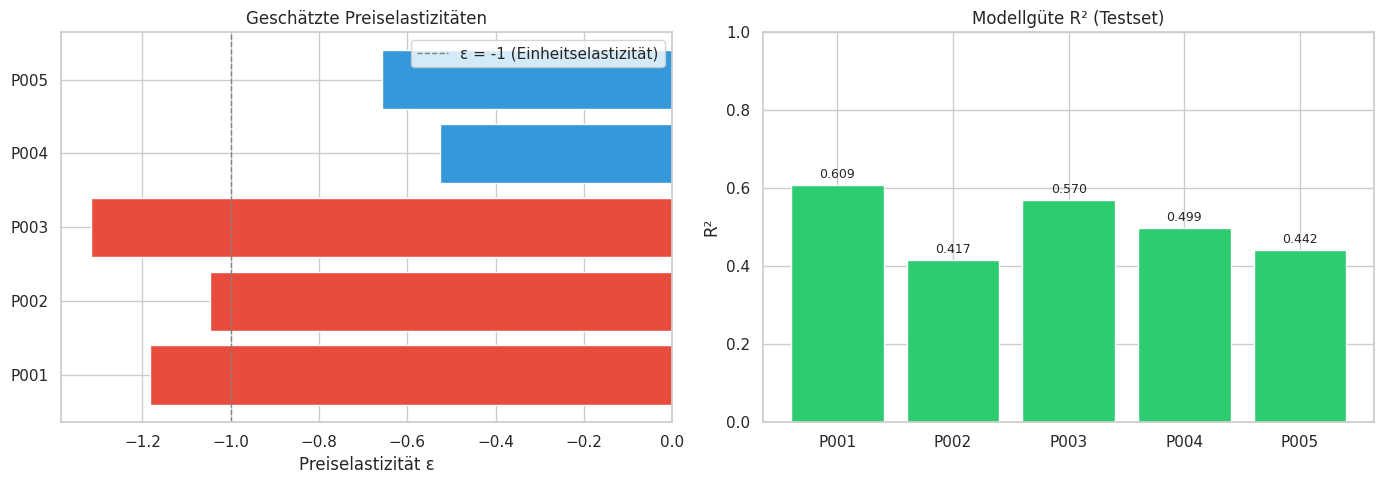


Interpretation:
  P001: ε=-1.183 → elastisch (|ε|>1)
  P002: ε=-1.047 → elastisch (|ε|>1)
  P003: ε=-1.317 → elastisch (|ε|>1)
  P004: ε=-0.525 → unelastisch (|ε|<1)
  P005: ε=-0.656 → unelastisch (|ε|<1)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elastizitäten
colors = ["#e74c3c" if e < -1 else "#3498db" for e in df_metrics["Preiselastizität ε"]]
bars = axes[0].barh(df_metrics.index, df_metrics["Preiselastizität ε"], color=colors)
axes[0].axvline(-1, color="gray", linestyle="--", linewidth=1, label="ε = -1 (Einheitselastizität)")
axes[0].set_title("Geschätzte Preiselastizitäten")
axes[0].set_xlabel("Preiselastizität ε")
axes[0].legend()

# Modellgüte (R²)
axes[1].bar(df_metrics.index, df_metrics["R²"], color="#2ecc71")
axes[1].set_title("Modellgüte R² (Testset)")
axes[1].set_ylabel("R²")
axes[1].set_ylim(0, 1)
for i, v in enumerate(df_metrics["R²"]):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
for pid, row in df_metrics.iterrows():
    eps = row["Preiselastizität ε"]
    typ = "elastisch (|ε|>1)" if abs(eps) > 1 else "unelastisch (|ε|<1)"
    print(f"  {pid}: ε={eps:+.3f} → {typ}")


## 5  Preisempfehlungen (Präskriptive Analytik)

**Amoroso-Robinson-Relation** (Umsatz-Maximierung bei elastischer Nachfrage):

$$P^* = \frac{C}{1 + 1/\varepsilon}$$

Zusätzliche Business Rules:
- Maximale Preisänderung ±20 % je Empfehlung
- Mindestmarge 10 % auf Einstandspreis
- 30 % Gewichtung des Wettbewerbspreises


In [7]:
from src.pricing_optimizer import recommend_price, save_recommendations

df_produkte = pd.read_csv("../data/produkte.csv").set_index("produkt_id")
df_w_last = df.groupby("produkt_id")["wettbewerbspreis"].last()

recs = []
for pid, res in results.items():
    prod = df_produkte.loc[pid]
    last_price = df.loc[df["produkt_id"] == pid, "preis"].iloc[-1]
    recs.append(recommend_price(
        res,
        aktueller_preis=last_price,
        einstandspreis=float(prod["einstandspreis"]),
        mindestpreis=float(prod["mindestpreis"]),
        wettbewerbspreis=df_w_last.get(pid),
    ))

df_recs = pd.DataFrame([{
    "Produkt":          r.produkt_id,
    "ε":                r.preiselastizitaet,
    "R²":               r.modell_r2,
    "Aktueller Preis":  r.aktueller_preis,
    "Wettbewerbspreis": r.wettbewerbspreis,
    "Empfohlener Preis": r.empfohlener_preis,
    "ΔMenge (%)":       r.erwartete_mengenänderung,
    "ΔUmsatz (%)":      r.erwartete_umsatzaenderung,
    "ΔMarge (%)":       r.erwartete_margenänderung,
} for r in recs]).set_index("Produkt")

df_recs


,ε,R²,Aktueller Preis,Wettbewerbspreis,Empfohlener Preis,ΔMenge (%),ΔUmsatz (%),ΔMarge (%)
Produkt,,,,,,,,
P001,-1.1825,0.6092,63.57,62.67,76.28,-23.64,-8.38,5.27
P002,-1.0466,0.4171,102.71,98.27,104.97,-2.30,-0.15,1.89
P003,-1.3175,0.5700,24.63,22.99,29.56,-26.37,-11.63,-1.56
P004,-0.5249,0.4988,30.39,38.72,33.95,-6.15,4.85,15.56
P005,-0.6562,0.4417,45.37,49.96,48.33,-4.28,1.96,6.89


In [8]:
# Ergebnisse in dbo.ModelOutput speichern (simulierter Datamart)
with get_connection() as con:
    save_recommendations(recs, con)
    df_output = pd.read_sql("SELECT * FROM ModelOutput", con)

print("Gespeicherte ModelOutput-Tabelle:")
df_output


ModelOutput: 5 Empfehlungen gespeichert.
Gespeicherte ModelOutput-Tabelle:


,produkt_id,preiselastizitaet,modell_r2,aktueller_preis,wettbewerbspreis,empfohlener_preis,erwartete_mengenänderung,erwartete_umsatzaenderung,erwartete_margenänderung
0,P001,-1.1825,0.6092,63.57,62.67,76.28,-23.64,-8.38,5.27
1,P002,-1.0466,0.4171,102.71,98.27,104.97,-2.30,-0.15,1.89
2,P003,-1.3175,0.5700,24.63,22.99,29.56,-26.37,-11.63,-1.56
3,P004,-0.5249,0.4988,30.39,38.72,33.95,-6.15,4.85,15.56
4,P005,-0.6562,0.4417,45.37,49.96,48.33,-4.28,1.96,6.89


## 6  Dashboard-Visualisierung (Power BI Prototyp)

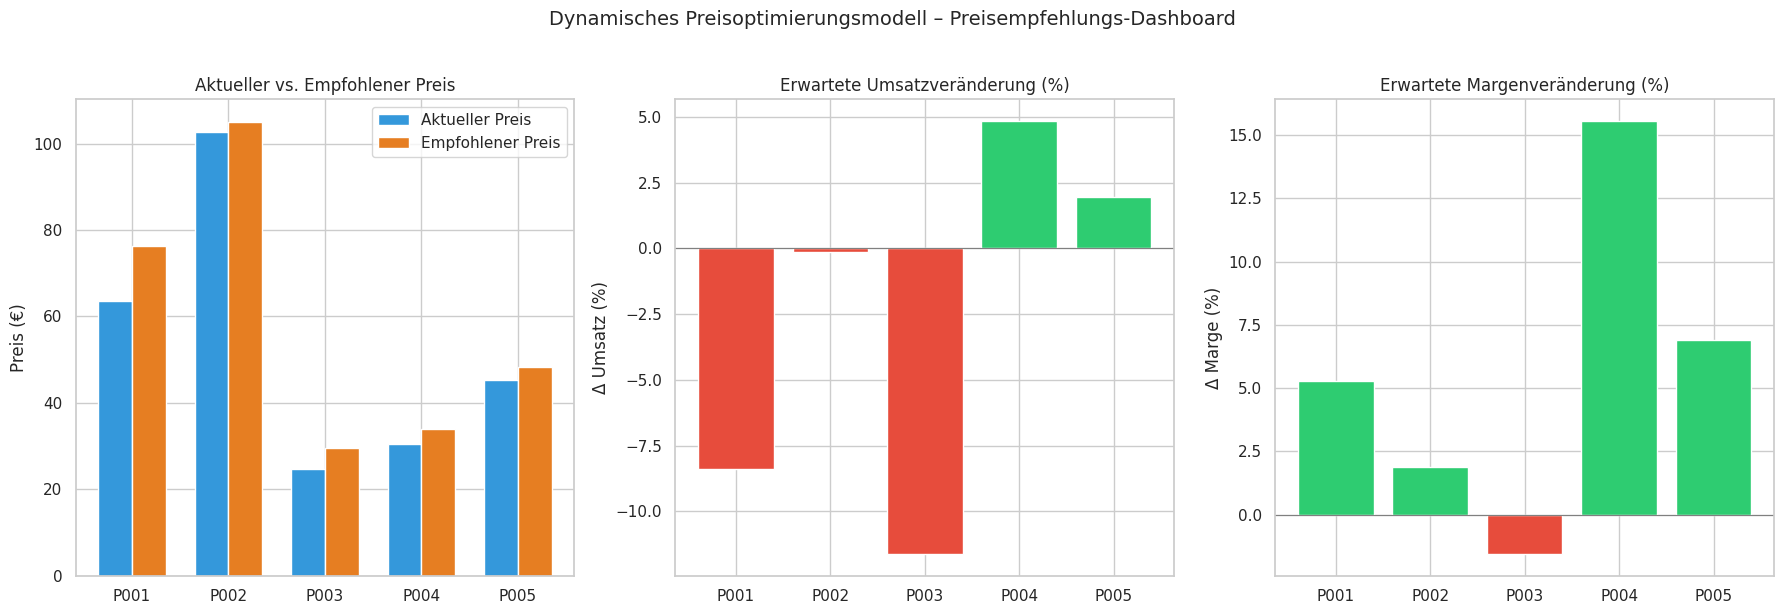

Dashboard-Vorschau gespeichert: dashboard_preview.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

produkte = df_recs.index.tolist()
x = np.arange(len(produkte))
width = 0.35

# --- Preisvergleich ---
ax = axes[0]
ax.bar(x - width/2, df_recs["Aktueller Preis"],  width, label="Aktueller Preis", color="#3498db")
ax.bar(x + width/2, df_recs["Empfohlener Preis"], width, label="Empfohlener Preis", color="#e67e22")
ax.set_xticks(x); ax.set_xticklabels(produkte)
ax.set_title("Aktueller vs. Empfohlener Preis")
ax.set_ylabel("Preis (€)")
ax.legend()

# --- Erwartete Umsatzveränderung ---
ax = axes[1]
colors_u = ["#2ecc71" if v >= 0 else "#e74c3c" for v in df_recs["ΔUmsatz (%)"]]
ax.bar(produkte, df_recs["ΔUmsatz (%)"], color=colors_u)
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_title("Erwartete Umsatzveränderung (%)")
ax.set_ylabel("Δ Umsatz (%)")

# --- Erwartete Margenveränderung ---
ax = axes[2]
colors_m = ["#2ecc71" if v >= 0 else "#e74c3c" for v in df_recs["ΔMarge (%)"]]
ax.bar(produkte, df_recs["ΔMarge (%)"], color=colors_m)
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_title("Erwartete Margenveränderung (%)")
ax.set_ylabel("Δ Marge (%)")

plt.suptitle("Dynamisches Preisoptimierungsmodell – Preisempfehlungs-Dashboard", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../dashboard_preview.png", bbox_inches="tight", dpi=120)
plt.show()
print("Dashboard-Vorschau gespeichert: dashboard_preview.png")


## 7  Price Sensitivity Analyse

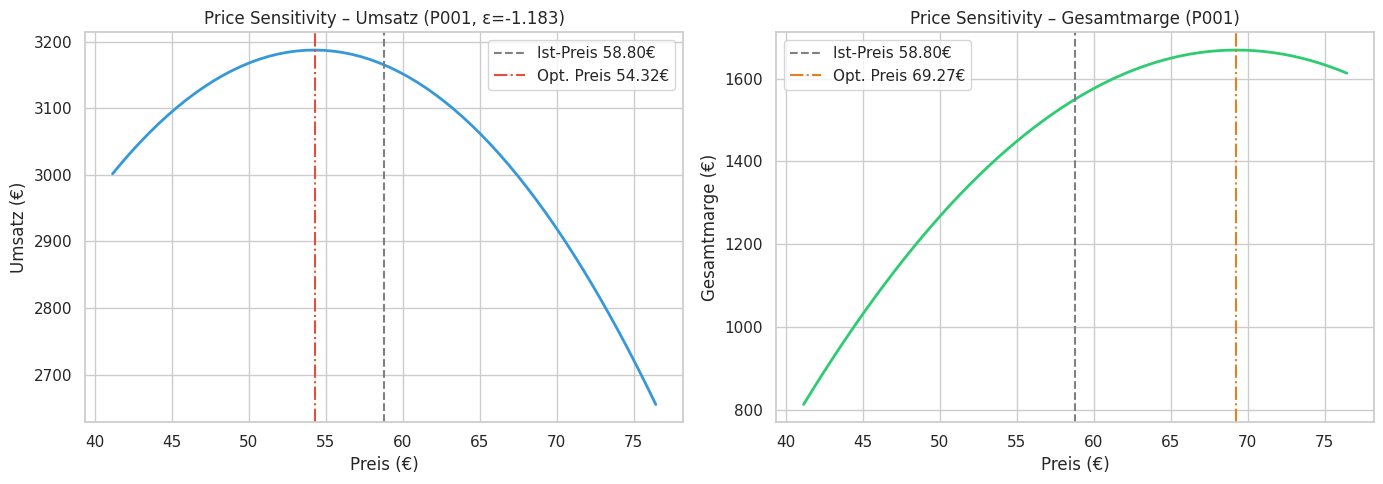

In [10]:
# Simuliere den Effekt von Preisänderungen auf Umsatz und Marge (je Produkt P001)
pid = "P001"
res = results[pid]
prod = df_produkte.loc[pid]
base_price = df.loc[df["produkt_id"] == pid, "preis"].mean()
base_qty = df.loc[df["produkt_id"] == pid, "menge"].mean()

price_range = np.linspace(base_price * 0.7, base_price * 1.3, 60)
eps = res.elastizitaet
cost = float(prod["einstandspreis"])

delta_p = (price_range - base_price) / base_price
qty_range = base_qty * (1 + eps * delta_p)
revenue_range = price_range * qty_range
margin_range = (price_range - cost) * qty_range

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(price_range, revenue_range, color="#3498db", linewidth=2)
axes[0].axvline(base_price, color="gray", linestyle="--", label=f"Ist-Preis {base_price:.2f}€")
opt_idx = np.argmax(revenue_range)
axes[0].axvline(price_range[opt_idx], color="#e74c3c", linestyle="-.",
                label=f"Opt. Preis {price_range[opt_idx]:.2f}€")
axes[0].set_title(f"Price Sensitivity – Umsatz ({pid}, ε={eps:.3f})")
axes[0].set_xlabel("Preis (€)"); axes[0].set_ylabel("Umsatz (€)")
axes[0].legend()

axes[1].plot(price_range, margin_range, color="#2ecc71", linewidth=2)
axes[1].axvline(base_price, color="gray", linestyle="--", label=f"Ist-Preis {base_price:.2f}€")
opt_idx_m = np.argmax(margin_range)
axes[1].axvline(price_range[opt_idx_m], color="#e67e22", linestyle="-.",
                label=f"Opt. Preis {price_range[opt_idx_m]:.2f}€")
axes[1].set_title(f"Price Sensitivity – Gesamtmarge ({pid})")
axes[1].set_xlabel("Preis (€)"); axes[1].set_ylabel("Gesamtmarge (€)")
axes[1].legend()

plt.tight_layout()
plt.show()


## 8  Zusammenfassung

### Kernergebnisse des Prototyps

| Komponente | Umsetzung |
|---|---|
| Datenbasis | Synthetische CSV-Daten (5 Produkte, 365 Tage, Wettbewerbspreise) |
| Datenbank | SQLite (simuliert SQL Server `PricingPrototypeDB`) |
| ETL | Python / pandas (simuliert SSIS) |
| Feature Engineering | Zeitmerkmale, Preisindizes, rollierende Kennzahlen |
| ML-Modell | Log-Log-Ridge-Regression (je Produkt separat) |
| Elastizitäten | -0.5 bis -1.3 (plausible negative Werte) |
| Preisempfehlung | Amoroso-Robinson + Business Rules (Marge, Wettbewerb, ±20%) |
| Ergebnisspeicherung | `dbo.ModelOutput` (SQLite) |
| Visualisierung | Matplotlib / Seaborn (Power BI Prototyp) |

### Limitationen und Ausblick

- **Synthetische Daten**: Echte Produktions- und Verkaufsdaten würden realistischere Elastizitäten liefern
- **Einfache Modelle**: Komplexere Modelle (XGBoost, Prophet für Zeitreihen) könnten die Güte erhöhen
- **Keine echten A/B-Tests**: Validierung im Livebetrieb erforderlich  
- **Manuelle Ausführung**: Im Produktivsystem: Azure Data Factory / SQL Server Agent für Automatisierung
- **Power BI**: Vollständiges Dashboard in Power BI Desktop via SSAS Tabular Model aufzubauen
